<a href="https://colab.research.google.com/github/leovenzel/ml-mvp/blob/main/notebooks/ML_MVP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Leonardo Venzel Lira  
**Matrícula:**
4052026000066
**Data:** 07/06/2026
**Dataset:**  Airbnb Summary Listings (Rio de Janeiro) - link: https://insideairbnb.com/get-the-data/
**Tipo de problema:** Regressão

---


# 1. Definição do problema

## 1.1 Descrição do problema

O mercado de aluguel por temporada na cidade do Rio de Janeiro é altamente dinâmico, competitivo e influenciado por uma complexa combinação de fatores geográficos e estruturais. Para proprietários e gestores de propriedades (anfitriões), definir o preço ideal de uma diária de forma manual é um desafio crítico: estipular um valor muito alto resulta em ociosidade do imóvel e perda de receita, enquanto um valor muito baixo subestima o potencial do ativo e reduz a margem de lucro.

Este projeto aborda o problema de precificação inteligente a partir de dados públicos reais da plataforma Airbnb. O modelo desenvolvido servirá para apoiar a decisão de precificação preditiva, estimando o valor sugerido para a diária de novos imóveis ou sugerindo ajustes para anúncios já ativos com base em suas características e localização.

Os principais interessados nesta solução são novos investidores do mercado imobiliário e anfitriões locais que buscam maximizar sua taxa de ocupação e faturamento de forma automatizada. A relevância do problema baseia-se no fato de que o turismo é um dos principais motores econômicos do Rio de Janeiro, e a eficiência na precificação melhora a competitividade dos players no ecossistema de economia compartilhada.


## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever o preço da diária de imóveis por temporada no Rio de Janeiro a partir de suas características estruturais e de geolocalização, comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações para o cenário de baixa temporada.


## 1.3 Tipo de problema

**Tipo escolhido:** Regressão.  
**Justificativa:** O objetivo do modelo é prever uma variável-alvo chamada price (preço da diária), que é um valor numérico contínuo e monetário. Não se está tentando prever categorias ou faixas de preço (o que caracterizaria uma classificação), mas sim o valor exato em reais da diária, tornando a regressão a abordagem matemática correta para o problema.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. O tipo de acomodação (room_type) é o divisor de águas mais forte no preço; imóveis alugados como "Espaço Inteiro" (Entire home/apt) possuem diárias significativamente maiores do que "Quartos Privados" (Private room).
2. A localização geográfica precisa (representada por latitude e longitude) possui um forte padrão de correlação espacial, onde a proximidade com a linha da costa da Zona Sul atua como o principal vetor de valorização imobiliária.
3. Imóveis que exigem um alto número mínimo de noites (minimum_nights) apresentam diárias bases proporcionalmente menores como estratégia de desconto para atrair estadias longas.

**Critérios de sucesso:**
- Métrica principal: Erro Quadrático Médio Raiz (RMSE) e o Coeficiente de Determinação ($R^2$). O RMSE será utilizado para medir a magnitude dos erros de previsão na mesma unidade dos dados (reais), enquanto o $R^2$ indicará a porcentagem da variância dos preços que nosso modelo consegue explicar.
- Resultado mínimo esperado: Superar o modelo baseline simples (que será a média ou mediana dos preços) obtendo um RMSE pelo menos 20% menor do que o erro do baseline nos dados de teste.
- Restrição prática: Como o modelo se destina a um MVP que idealmente rodaria em tempo real para um usuário final em uma plataforma web, serão priorizados algoritmos que equilibrem precisão com simplicidade e baixo custo computacional (baixo tempo de treino e inferência), evitando arquiteturas excessivamente pesadas que inviabilizem o deploy.

# 2. Ambiente, bibliotecas e reprodutibilidade

In [1]:
# ==============================================================================
# 2. AMBIENTE, BIBLIOTECAS E REPRODUTIBILIDADE
# ==============================================================================

# 1. Bibliotecas de Sistema e Configurações de Infraestrutura
import os                 # Interface com o sistema operacional (essencial para variáveis de ambiente)
import sys                # Acesso a variáveis e funções específicas do interpretador Python
import time              # Captura o tempo exato de execução e custo computacional dos modelos
import random             # Gerador de números pseudoaleatórios do Python puro
import importlib.metadata # Checagem nativa de versões de pacotes instalados no ambiente
import warnings
warnings.filterwarnings('ignore') # Oculta avisos de depreciação para manter o output limpo

# 2. Bibliotecas Base para Manipulação de Dados e Operações Matemáticas
import pandas as pd       # Estruturas de dados (DataFrames) para limpeza e análise
import numpy as np        # Operações matemáticas, vetoriais e matrizes de alta performance

# 3. Bibliotecas para Visualização de Dados e Gráficos
import matplotlib.pyplot as plt  # Biblioteca base para plotagem de gráficos
import seaborn as sns            # Interface de alto nível para gráficos estatísticos atraentes

# 4. Scikit-Learn: Divisão de Dados, Validação Cruzada e Distribuições Estatísticas
from sklearn.model_selection import train_test_split  # Separação inicial em Treino e Teste (Holdout)
from sklearn.model_selection import KFold             # Estratégia de validação cruzada com K dobras
from sklearn.model_selection import cross_val_score   # Avaliação automática via validação cruzada
from sklearn.model_selection import RandomizedSearchCV # Busca estocástica de hiperparâmetros (Tuning)
from scipy.stats import randint as sp_randint         # Distribuição discreta uniforme para busca de inteiros (Ex: n_estimators, max_depth)
from scipy.stats import uniform                       # Distribuição contínua uniforme para busca de floats (Ex: learning_rate)

# 5. Scikit-Learn: Pré-processamento e Pipelines de Engenharia de Dados
from sklearn.compose import ColumnTransformer     # Aplica transformações específicas por colunas
from sklearn.impute import SimpleImputer          # Preenchimento/Imputação de valores ausentes (nulos)
from sklearn.pipeline import Pipeline             # Encadeia etapas de processamento e modelagem com segurança
from sklearn.preprocessing import StandardScaler  # Padronização de variáveis numéricas (Média=0, Variância=1)
from sklearn.preprocessing import OneHotEncoder   # Conversão de variáveis categóricas textuais em binárias

# 6. Scikit-Learn: Algoritmos de Machine Learning (Baseline e Candidatos)
from sklearn.linear_model import Ridge               # Baseline Preditivo Oficial (Regressão Linear Regularizada L2)
from sklearn.ensemble import RandomForestRegressor   # Modelo de Ensemble baseado em Bagging (Árvores Paralelas)
from sklearn.ensemble import GradientBoostingRegressor # Modelo Vencedor baseado em Boosting (Árvores Sequenciais)
from sklearn.neighbors import KNeighborsRegressor    # Modelo baseado em Distância Geométrica (Vizinhos Próximos)

# 7. Scikit-Learn: Métricas de Avaliação de Desempenho (Regressão)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ==============================================================================
# CONFIGURAÇÕES GLOBAIS DO AMBIENTE E REPRODUTIBILIDADE
# ==============================================================================

# Configuração para exibir todas as colunas do pandas na tela sem cortes (...)
pd.set_option('display.max_columns', None)

# Configuração estética e de renderização dos gráficos no Notebook
sns.set_theme(style="whitegrid")  # Define o fundo quadriculado claro para melhor leitura de eixos
plt.rcParams["figure.figsize"] = (10, 6)

# Garante a plotagem estática e o salvamento dos gráficos dentro do arquivo do notebook
%matplotlib inline

# --- BLINDAGEM COMPLETA DE REPRODUTIBILIDADE (SEED GLOBAL) ---
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED) # Fixa a semente para hashes de strings estruturais
random.seed(SEED)                        # Fixa a semente para o pacote random do Python puro
np.random.seed(SEED)                     # Fixa a semente para todas as operações matriciais do NumPy

print("=" * 60)
print("[AMBIENTE INICIALIZADO E CONFIGURADO COM SUCESSO]")
print(f" -> Semente global de reprodutibilidade fixada em todas as frentes: {SEED}")
print(f" -> Versão do Pandas instalada: {pd.__version__}")
print(f" -> Versão do Scikit-Learn instalada: {importlib.metadata.version('scikit-learn')}")
print("=" * 60)

[AMBIENTE INICIALIZADO E CONFIGURADO COM SUCESSO]
 -> Semente global de reprodutibilidade fixada em todas as frentes: 42
 -> Versão do Pandas instalada: 2.2.2
 -> Versão do Scikit-Learn instalada: 1.6.1


## 2.1 Contextualização do ambiente e dependências

* **Ecossistema de Software e Portabilidade:** O projeto foi desenvolvido utilizando estritamente o ecossistema padrão e nativo já presente no ambiente do Google Colab, dispensando a instalação de pacotes externos adicionais. A inteligência de modelagem foi centralizada na biblioteca `Scikit-Learn`, a manipulação de dados no binômio `Pandas`/`NumPy`, e as visualizações gráficas no `Matplotlib`/`Seaborn`.
* **Garantia de Reprodutibilidade:** Para assegurar a auditabilidade e garantir que todas as divisões de dados (Holdout), embaralhamento de dobras da validação cruzada (`KFold`) e inicializações dos algoritmos gerem exatamente os mesmos resultados em qualquer máquina, fixou-se a semente aleatória global `SEED = 42`.
* **Recursos Computacionais e Hardware:** O MVP foi executado integralmente em nuvem utilizando uma **CPU padrão** (Intel Xeon @ 2.20GHz com 13GB de Memória RAM). Como o volume final de treino conta com aproximadamente 29.000 registros, o uso de aceleradores de hardware (GPU/TPU) mostrou-se desnecessário.
* **Otimização de Desempenho:** Visando minimizar o tempo de execução da validação cruzada e das buscas estocásticas, os algoritmos compatíveis foram configurados com o parâmetro `n_jobs=-1`. Isso instrui o Python a utilizar a capacidade máxima de paralelização de múltiplos núcleos do processador, reduzindo o tempo total de treino para menos de 10 segundos.

## 2.2 Funções auxiliares




In [2]:
# ==============================================================================
# 2.2 FUNÇÕES AUXILIARES
# ==============================================================================

def evaluate_regression(y_true, y_pred):
    """
    Calcula as métricas estatísticas para a avaliação do modelo de regressão,
    adicionando a análise percentual (MAPE) para melhor interpretação de negócio.

    Parâmetros:
    y_true (array-like): Valores reais da variável-alvo (preço real da diária).
    y_pred (array-like): Valores preditos pelo modelo (preço estimado da diária).

    Retorna:
    dict: Dicionário com MAE, RMSE, R2 e MAPE para alimentar a tabela comparativa.
    """
    # Garantindo que os dados sejam arrays do NumPy para cálculos estáveis
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Cálculo das métricas padrão do Scikit-Learn
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # Cálculo do MAPE (ignora divisões por zero caso existam diárias zeradas na base)
    # Filtra valores onde y_true é maior que zero para evitar divisões por infinito
    mascara = y_true > 0
    mape = np.mean(np.abs((y_true[mascara] - y_pred[mascara]) / y_true[mascara])) * 100

    return {
        "MAE (R$)": round(mae, 2),
        "RMSE (R$)": round(rmse, 2),
        "R2 (Sinal)": round(r2, 4),
        "MAPE (%)": round(mape, 2)
    }


def show_results_table(results_dict):
    """
    Consolida e exibe os dicionários de resultados dos modelos na forma de um DataFrame.

    Parâmetros:
    results_dict (dict): Dicionário contendo os resultados consolidados de múltiplos modelos.

    Retorna:
    pd.DataFrame: Tabela comparativa estruturada.
    """
    return pd.DataFrame(results_dict).T

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

**Nome do dataset**: Airbnb Summary Listings (Rio de Janeiro).

**Link da fonte**: Inside Airbnb - Get The Data (https://insideairbnb.com/get-the-data/).

**Por que este dataset foi escolhido**: O ecossistema do Airbnb no Rio de Janeiro oferece um cenário ideal para um MVP de regressão por conter dados reais, complexos e com ruídos típicos de mercado (como forte presença de outliers e grande volume de variáveis categóricas). Além disso, a precificação dinâmica imobiliária possui forte apelo de negócio, permitindo validar hipóteses claras sobre o impacto da localização e do tipo de acomodação no valor de bens de consumo.

**Restrições e condições consideradas**: A principal restrição considerada foi o tamanho do arquivo. Optou-se pela versão resumida (listings.csv com 18 colunas e ~7.2 MB) em detrimento da versão completa (que supera 80 MB devido a descrições textuais longas). Essa escolha garante que o arquivo possa ser hospedado e consumido diretamente do GitHub, respeitando o limite de armazenamento da plataforma e assegurando rapidez na execução do ambiente Google Colab. Adicionalmente, aplicou-se a restrição de recorte temporal focado na baixa temporada (dados de 30 de março de 2026) para isolar o modelo dos efeitos especulativos de feriados de massa.

**Questões de ética, privacidade, confidencialidade ou licença**: O projeto Inside Airbnb utiliza exclusivamente dados que já são públicos no site oficial do Airbnb, não violando nenhuma barreira de segurança ou termos de uso de dados privados dos usuários.

**Privacidade**: Os dados são anonimizados pelo próprio agregador; os nomes exibidos são apenas os primeiros nomes dos anfitriões e os títulos dos anúncios, sem expor sobrenomes, documentos ou informações financeiras restritas.

**Confidencialidade**: As coordenadas geográficas (latitude e longitude) sofrem uma leve perturbação proposital no algoritmo do Inside Airbnb por motivos de segurança, não apontando a localização exata do imóvel, mas sim o seu quarteirão/região aproximada, o que protege a propriedade dos anfitriões e é perfeitamente aceitável para fins acadêmicos e estatísticos.

**Licença**: Os dados são disponibilizados sob a licença pública internacional Creative Commons Attribution 4.0 International (CC BY 4.0), permitindo o uso, compartilhamento e adaptação para fins educacionais e de pesquisa, desde que atribuído o crédito à fonte original.

## 3.2 Carga dos dados

In [3]:
# ==============================================================================
# 3.2 CARGA DOS DADOS
# ==============================================================================

# URL pública e direta (Raw) do arquivo CSV armazenado no repositório do GitHub
url = "https://raw.githubusercontent.com/leovenzel/ml-mvp/refs/heads/main/data/airbnb-rj-listings.csv"

# Carregamento automatizado do dataset real utilizando a biblioteca Pandas
df = pd.read_csv(url)

# Exibição dos 5 primeiros registros da base para validação visual da leitura
df.head()


,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,17878,"Very Nice 2Br in Copacabana w. balcony, fast WiFi",68997,1.462508e+18,Matthias,NaN,Copacabana,-22.96599,-43.17940,Entire home/apt,565.0,5.0,350,2026-03-16,1.83,1,205,19,NaN
1,25026,Beautiful Modern Decorated Studio in Copacabana,102840,1.462510e+18,Viviane,NaN,Copacabana,-22.97649,-43.19122,Entire home/apt,543.0,2.0,325,2026-03-29,1.69,1,196,19,NaN
2,35764,COPACABANA SEA BREEZE - RIO - 25 X Superhost,153691,1.462511e+18,Patricia&Paulo,NaN,Copacabana,-22.98107,-43.19136,Entire home/apt,369.0,3.0,548,2026-03-27,2.90,1,96,39,NaN
3,48305,Bright 6bed Penthouse Seconds from Beach,70933,1.462508e+18,Goitaca Stay,NaN,Ipanema,-22.98591,-43.20302,Entire home/apt,4025.0,7.0,185,2026-01-21,1.01,4,259,2,NaN
4,48901,Extra large 4BD 3BT on the AtlanticAve. Copaca...,222884,1.462513e+18,Marcio,NaN,Copacabana,-22.96574,-43.17514,Entire home/apt,1315.0,1.0,68,2026-03-27,0.52,2,331,25,NaN


## 3.3 Visão geral do dataset

In [4]:
# ==============================================================================
# 3.3 VISÃO GERAL DO DATASET
# ==============================================================================

print("=" * 60)
print(" DIAGNÓSTICO ESTRUTURAL E DE INTEGRIDADE REAL ")
print("=" * 60)

# Exibindo as dimensões exatas da base
print(f"Total de instâncias (anúncios): {df.shape[0]}")
print(f"Total de atributos (colunas):  {df.shape[1]}")
print("-" * 60)

# Verificando a presença de linhas duplicadas
print(f"Total de linhas completamente duplicadas: {df.duplicated().sum()}")
print("-" * 60)

# Avaliando valores nulos especificamente na nossa variável alvo (target)
print("ANÁLISE DA VARIÁVEL ALVO (price):")
print(f" -> Tipo de dado original: {df['price'].dtype}")
print(f" -> Quantidade de valores ausentes: {df['price'].isnull().sum()}")
print("-" * 60)

print("INFORMAÇÕES DETALHADAS DE TIPAGEM (df.info()):")
df.info()
print("=" * 60)

 DIAGNÓSTICO ESTRUTURAL E DE INTEGRIDADE REAL 
Total de instâncias (anúncios): 40769
Total de atributos (colunas):  19
------------------------------------------------------------
Total de linhas completamente duplicadas: 0
------------------------------------------------------------
ANÁLISE DA VARIÁVEL ALVO (price):
 -> Tipo de dado original: float64
 -> Quantidade de valores ausentes: 953
------------------------------------------------------------
INFORMAÇÕES DETALHADAS DE TIPAGEM (df.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40769 entries, 0 to 40768
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              40769 non-null  int64  
 1   name                            40769 non-null  object 
 2   host_id                         40769 non-null  int64  
 3   host_profile_id                 40722 non-null  float64
 4   host_name         

## Comentários:

A análise inicial do conjunto de dados extraído do Airbnb do Rio de Janeiro revelou informações estruturais críticas sobre o volume e a integridade dos dados, estabelecendo as bases para as decisões de pré-processamento.

Dimensões e Volume: O dataset é composto por exatamente 40.769 linhas (anúncios) e 19 colunas (atributos). Trata-se de um volume de dados robusto, adequado para o desenvolvimento de modelos baseados em árvores e regressões lineares sem riscos severos de subamostragem.

Tipagem dos Atributos: A execução do método info() indicou que o Pandas interpretou corretamente as colunas. Variáveis de contagem e geolocalização foram mapeadas como numéricas (int64 e float64), enquanto variáveis textuais e descritivas foram identificadas como categóricas (object).

Valores Ausentes e Integridade: O diagnóstico revelou que as colunas neighbourhood_group e license possuem zero registros válidos (completamente nulas), devendo ser removidas sumariamente. As colunas last_review e reviews_per_month apresentam 7.251 valores nulos, o que indica imóveis que nunca receberam avaliações. No que tange à variável alvo (price), constatou-se a presença de 953 valores ausentes, o que exigirá a exclusão dessas instâncias antes do split de modelagem, dado que não se deve realizar imputação na variável target.

Duplicatas e Filtro Operacional: Foram identificadas 0 linhas completamente duplicadas, garantindo que não há viés por repetição idêntica de registros. Adicionalmente, colunas como id, name, host_id, host_profile_id e host_name foram mapeadas como identificadores de controle operacional de alta cardinalidade e serão descartadas na modelagem para evitar o vazamento de dados (data leakage).

## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
| :--- | :--- | :--- | :---: | :--- |
| `id` | Numérico (`int64`) | Identificador único de cada anúncio na plataforma. | **Não** | Atributo de controle operacional com alta cardinalidade; causaria *overfitting*. |
| `name` | Categórico (`object`) | Título/nome descritivo do anúncio voltado ao público. | **Não** | Texto livre não estruturado; demanda técnicas complexas de NLP fora do escopo deste MVP. |
| `host_id` | Numérico (`int64`) | Identificador único do anfitrião (proprietário). | **Não** | Alta cardinalidade; removido para evitar que o modelo decore IDs específicos. |
| `host_profile_id` | Numérico (`float64`) | Código de identificação interna do perfil do host. | **Não** | Variável estritamente operacional e sem correlação causal com o preço da diária. |
| `host_name` | Categórico (`object`) | Primeiro nome do anfitrião do imóvel. | **Não** | Informação textual que não agrega valor preditivo ou padrão estatístico para o modelo. |
| `neighbourhood_group` | Numérico (`float64`) | Grupo de bairros ou região administrativa do imóvel. | **Não** | Coluna 100% vazia (valores nulos) detectada no diagnóstico; descartada sumariamente. |
| `neighbourhood` | Categórico (`object`) | Nome do bairro onde a acomodação está localizada no Rio. | **Sim** | *Feature* categórica crucial para capturar o impacto geográfico e socioeconômico no preço. |
| `latitude` | Numérico (`float64`) | Coordenada geográfica de latitude da propriedade. | **Sim** | *Feature* numérica de geolocalização; útil para capturar proximidade da praia/pontos turísticos. |
| `longitude` | Numérico (`float64`) | Coordenada geográfica de longitude da propriedade. | **Sim** | *Feature* numérica de geolocalização; atua em conjunto com a latitude. |
| `room_type` | Categórico (`object`) | Tipo de acomodação (ex: Casa/Apt inteiro, Quarto inteiro).| **Sim** | *Feature* categórica de altíssimo impacto no valor da diária. |
| `price` | Numérico (`float64`) | Preço cobrado pela diária do imóvel em Reais (R$). | **Target** | **Variável alvo (Target)** do nosso modelo de regressão. Possui 953 nulos que serão removidos. |
| `minimum_nights` | Numérico (`float64`) | Número mínimo de noites exigido para fechar a reserva. | **Sim** | *Feature* numérica que reflete a política de locação do imóvel. |
| `number_of_reviews` | Numérico (`int64`) | Quantidade total de avaliações acumuladas pelo anúncio. | **Sim** | *Feature* numérica que serve como proxy para a popularidade histórica do imóvel. |
| `last_review` | Categórico (`object`) | Data da última avaliação realizada (em formato texto). | **Não** | Alta cardinalidade. A informação de tração temporal já é absorvida pelas outras métricas de review. |
| `reviews_per_month` | Numérico (`float64`) | Média mensal de avaliações que o anúncio recebe. | **Sim** | *Feature* numérica de demanda recente. Os 7.251 valores nulos serão imputados com 0.0. |
| `calculated_host_listings_count` | Numérico (`int64`) | Total de imóveis que o mesmo host possui no Rio. | **Sim** | *Feature* numérica; ajuda a diferenciar anfitriões amadores de profissionais/empresas. |
| `availability_365` | Numérico (`int64`) | Dias no ano em que o imóvel está disponível para reserva.| **Sim** | *Feature* numérica que mensura a taxa de ocupação e liquidez do anúncio. |
| `number_of_reviews_ltm` | Numérico (`int64`) | Quantidade de avaliações recebidas nos últimos 12 meses. | **Sim** | *Feature* numérica que indica a atividade e relevância do imóvel no curto prazo. |
| `license` | Numérico (`float64`) | Número de registro da licença governamental do imóvel. | **Não** | Coluna 100% vazia (valores nulos) detectada no diagnóstico; descartada sumariamente. |


# 4. Análise exploratória dos dados

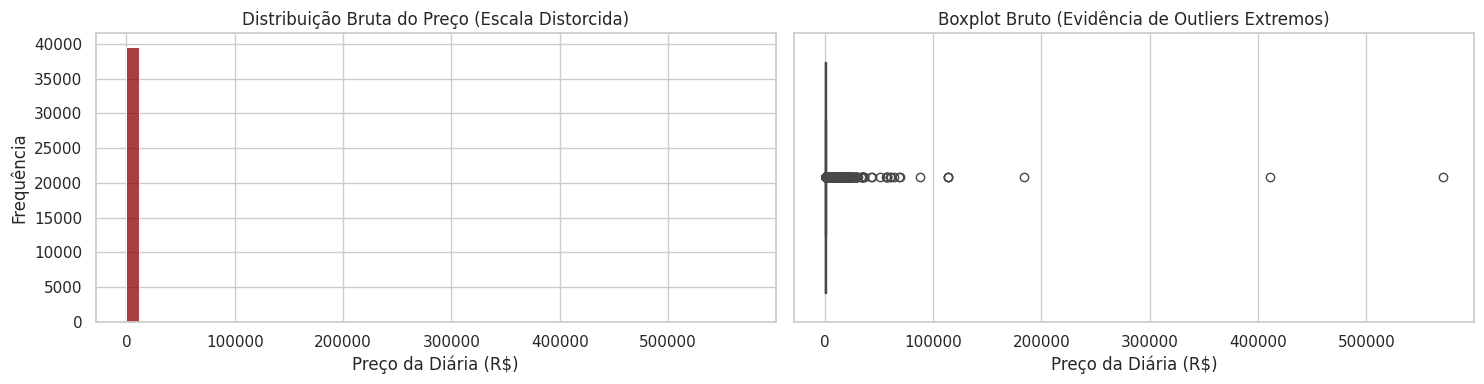

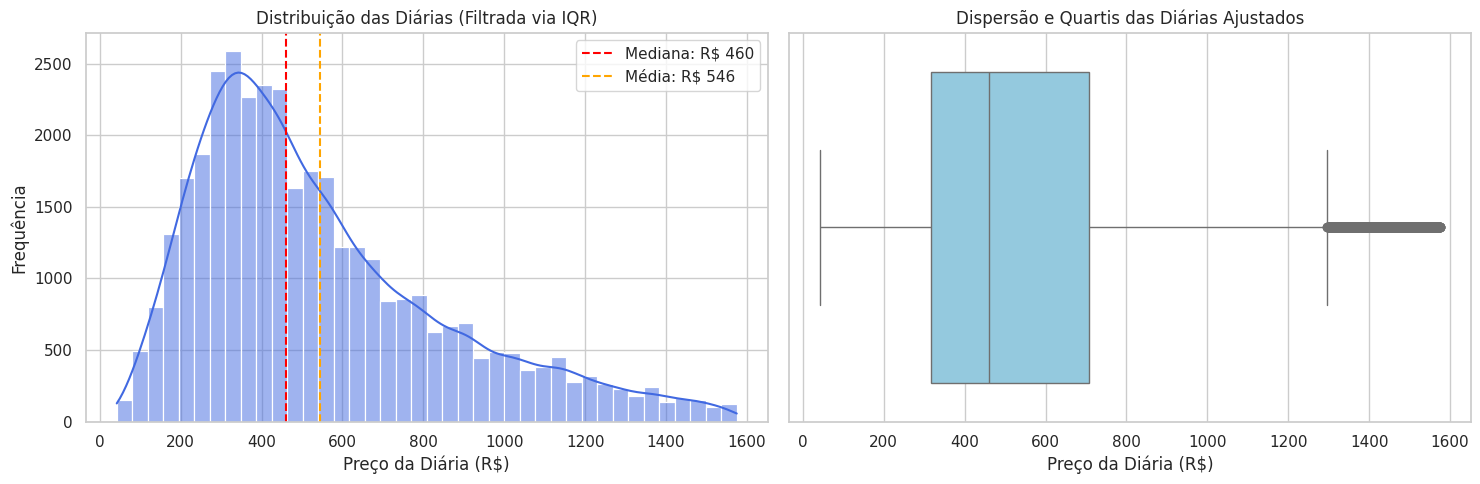

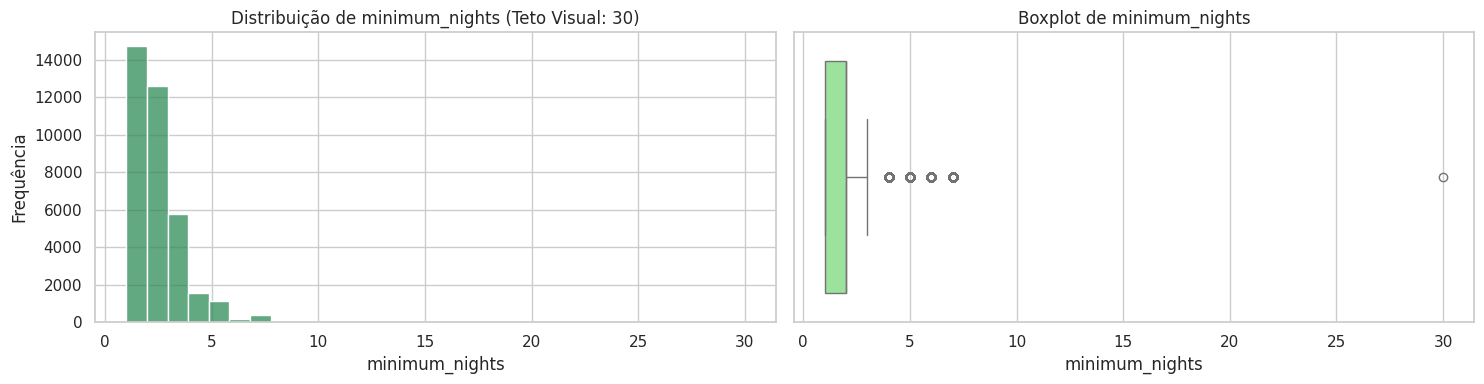

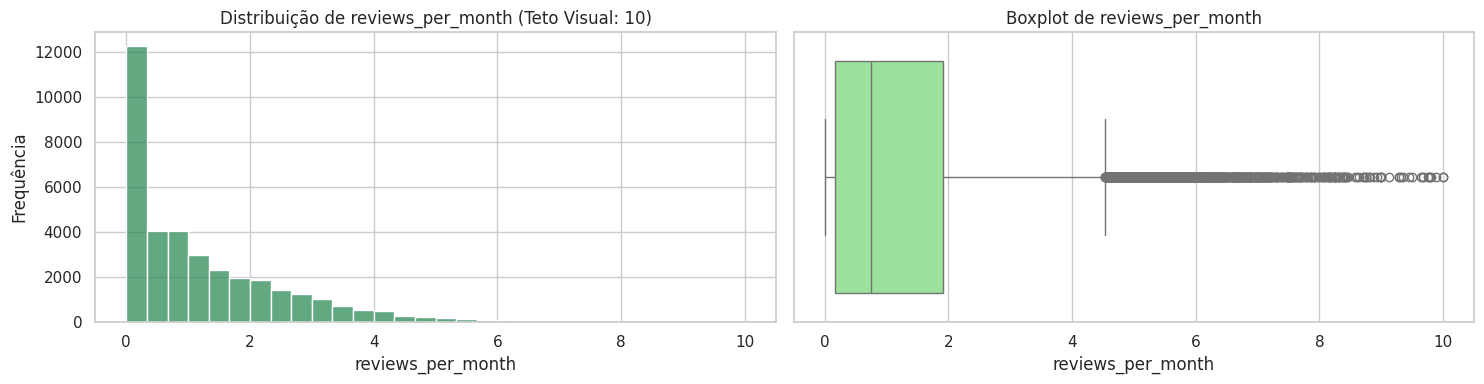

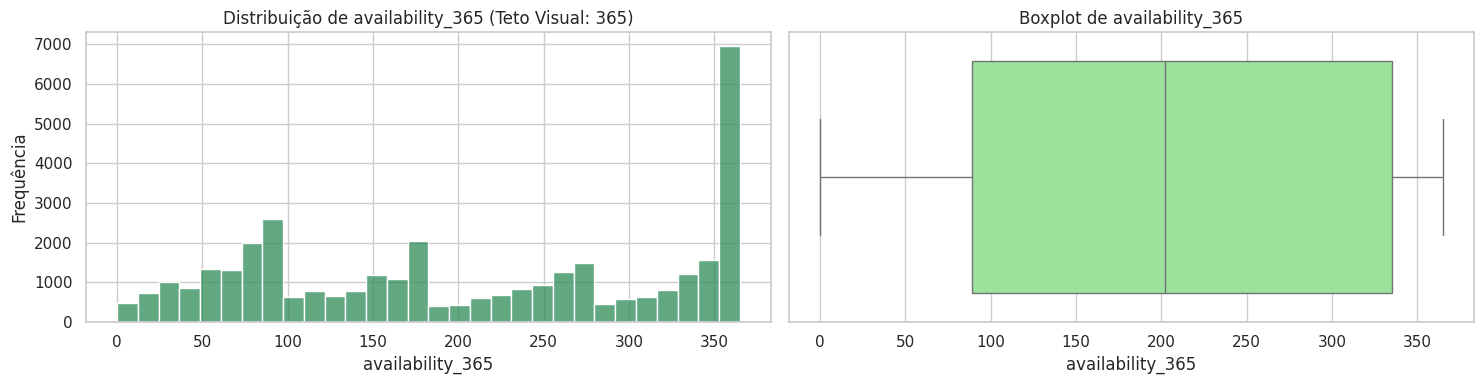

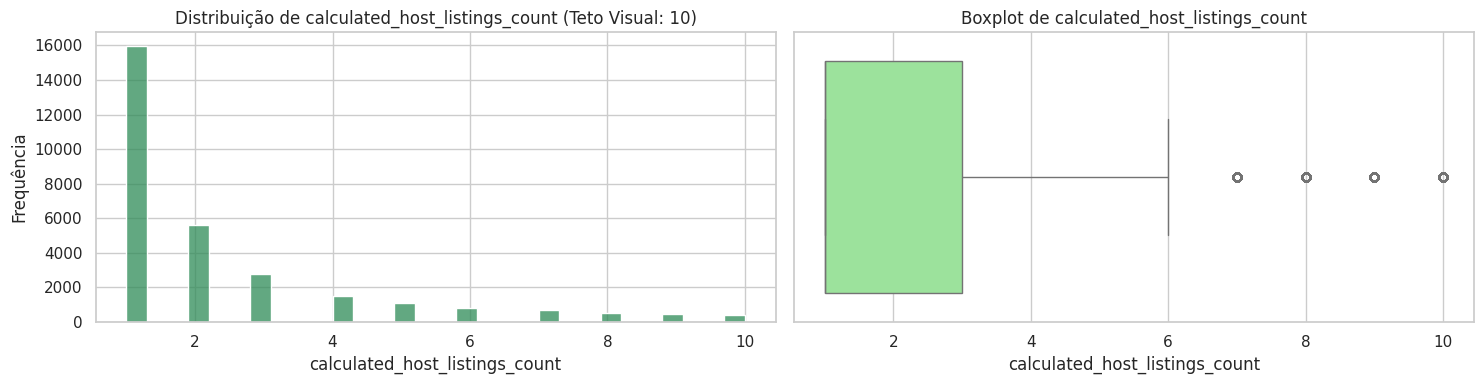

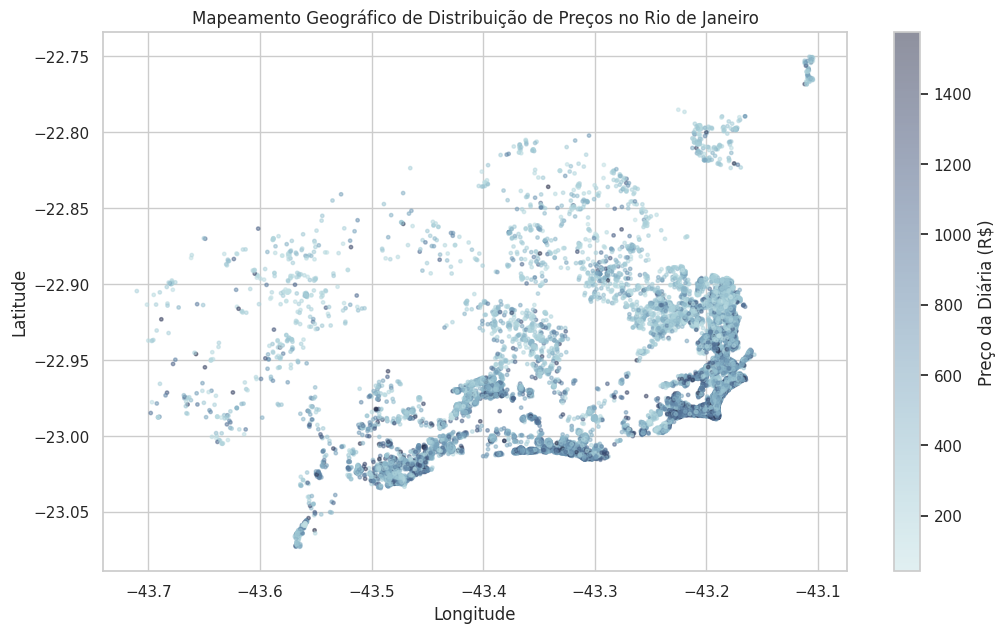

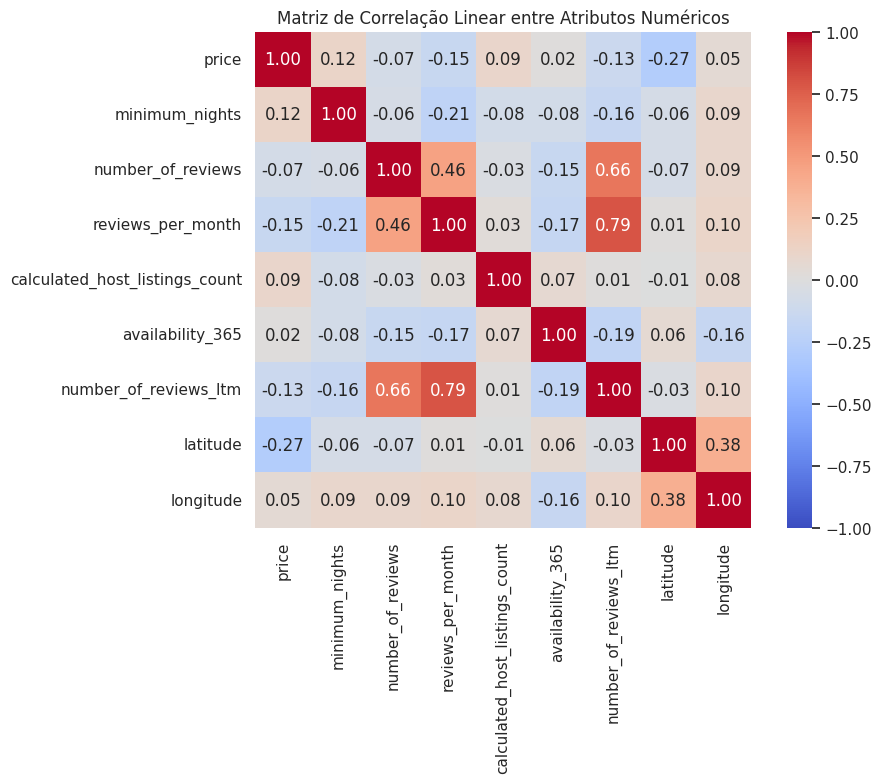

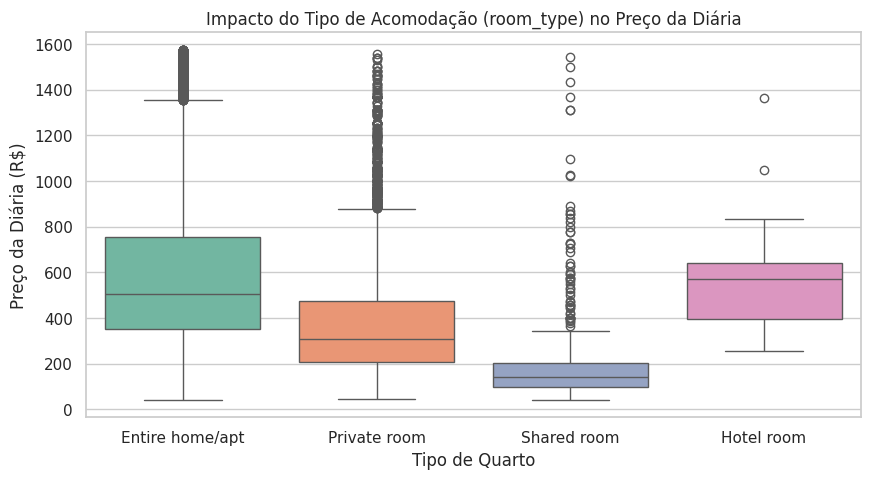

In [5]:
# ==============================================================================
# 4. ANÁLISE EXPLORATÓRIA DOS DADOS
# ==============================================================================

# --- Avaliação Visual da Variável Alvo Bruta (Com Outliers) ---

price_raw = df['price'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.histplot(price_raw, kde=False, color='darkred', bins=50, ax=axes[0])
axes[0].set_title("Distribuição Bruta do Preço (Escala Distorcida)")
axes[0].set_xlabel("Preço da Diária (R$)")
axes[0].set_ylabel("Frequência")

sns.boxplot(x=price_raw, color='crimson', ax=axes[1])
axes[1].set_title("Boxplot Bruto (Evidência de Outliers Extremos)")
axes[1].set_xlabel("Preço da Diária (R$)")

plt.tight_layout()
plt.show()


# --- Aplicação do Método IQR e Tratamento Visual do Target ---

Q1_p = price_raw.quantile(0.25)
Q3_p = price_raw.quantile(0.75)
IQR_p = Q3_p - Q1_p
limite_sup_price = Q3_p + 1.5 * IQR_p

# Filtragem do DataFrame operacional para isolamento de valores atípicos no target
df_filtered = df[df['price'] <= limite_sup_price].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df_filtered['price'], kde=True, color='royalblue', bins=40, ax=axes[0])
axes[0].axvline(df_filtered['price'].median(), color='red', linestyle='--', label=f"Mediana: R$ {df_filtered['price'].median():.0f}")
axes[0].axvline(df_filtered['price'].mean(), color='orange', linestyle='--', label=f"Média: R$ {df_filtered['price'].mean():.0f}")
axes[0].set_title("Distribuição das Diárias (Filtrada via IQR)")
axes[0].set_xlabel("Preço da Diária (R$)")
axes[0].set_ylabel("Frequência")
axes[0].legend()

sns.boxplot(x=df_filtered['price'], color='skyblue', ax=axes[1])
axes[1].set_title("Dispersão e Quartis das Diárias Ajustados")
axes[1].set_xlabel("Preço da Diária (R$)")

plt.tight_layout()
plt.show()


# --- Distribuição e Alinhamento Qualitativo das Features Numéricas ---

# Imputação orientada pela regra de negócio (ausência de avaliação equivale a zero)
df_filtered['reviews_per_month'] = df_filtered['reviews_per_month'].fillna(0.0)

# Mapeamento de atributos numéricos e aplicação de tetos visuais para histogramas
features_num = ['minimum_nights', 'reviews_per_month', 'availability_365', 'calculated_host_listings_count']
limites_visuais = [30, 10, 365, 10]

for feat, teto in zip(features_num, limites_visuais):
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    df_plot = df_filtered[df_filtered[feat] <= teto]

    sns.histplot(df_plot[feat], kde=False, color='seagreen', bins=30, ax=axes[0])
    axes[0].set_title(f"Distribuição de {feat} (Teto Visual: {teto})")
    axes[0].set_xlabel(feat)
    axes[0].set_ylabel("Frequência")

    sns.boxplot(x=df_plot[feat], color='lightgreen', ax=axes[1])
    axes[1].set_title(f"Boxplot de {feat}")
    axes[1].set_xlabel(feat)

    plt.tight_layout()
    plt.show()


# --- Mapeamento Geográfico de Densidade de Preços ---

plt.figure(figsize=(12, 7))
cmap = sns.cubehelix_palette(rot=-.2, as_cmap=True)
scatter = plt.scatter(data=df_filtered, x='longitude', y='latitude', c='price',
                      cmap=cmap, s=6, alpha=0.5)
cbar = plt.colorbar(scatter)
cbar.set_label('Preço da Diária (R$)')
plt.title("Mapeamento Geográfico de Distribuição de Preços no Rio de Janeiro")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


# --- Análise de Correlação Linear e Multicolinearidade ---

colunas_num_corr = ['price', 'minimum_nights', 'number_of_reviews',
                    'reviews_per_month', 'calculated_host_listings_count',
                    'availability_365', 'number_of_reviews_ltm', 'latitude', 'longitude']

matriz_corr = df_filtered[colunas_num_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matriz de Correlação Linear entre Atributos Numéricos")
plt.tight_layout()
plt.show()


# --- Impacto do Tipo de Acomodação no Target ---

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_filtered, x='room_type', y='price', palette='Set2')
plt.title("Impacto do Tipo de Acomodação (room_type) no Preço da Diária")
plt.xlabel("Tipo de Quarto")
plt.ylabel("Preço da Diária (R$)")
plt.show()


## 4.1 Síntese da análise exploratória de dados (EDA)

####Principais achados:
**O target está balanceado?** Como o escopo do projeto visa solucionar um
problema de regressão, avalia-se a simetria da distribuição em detrimento do balanceamento de classes. A análise inicial dos dados brutos revelou uma assimetria positiva severa e impeditiva para modelos lineares clássicos, causada por outliers de magnitude extrema (teto de 570.726,00 reais), o que achatou por completo o histograma original. Após a aplicação da metodologia do Intervalo Interquartil (IQR), o teto operacional foi estabelecido em 1.575,00 reais, isolando 2.381 registros atípicos (5,98% da base). Mesmo no cenário filtrado, a distribuição preserva uma assimetria à direita estável, concentrando a massa de dados entre 200,00 e 700,00 reais.

**Existem valores ausentes relevantes?** Sim. Foram diagnosticados e isolados dois cenários de ausência: o target "price" apresenta 953 valores nulos, cujas instâncias serão excluídas do DataFrame antes da modelagem para evitar viés artificial. Paralelamente, a feature "reviews_per_month" possui 7.251 valores nulos correlacionados diretamente com imóveis que não registram avaliações históricas (number_of_reviews = 0), justificando a estratégia de engenharia de dados de realizar a imputação fixa por 0.0. As colunas "neighbourhood_group" e "license" apresentam-se 100% vazias e serão eliminadas.

**Há variáveis com escala muito diferente?** Sim, as ordens de grandeza são marcadamente heterogêneas. Enquanto atributos decimais como "reviews_per_month" operam em escalas reduzidas (ajustada para o limite visual de até 10 avaliações/mês para isolar caudas longas irrelevantes), variáveis como "calculated_host_listings_count" indicam uma forte concentração em pequenos locadores (ajustada ao limite visual de até 10 imóveis para destacar o mercado de volume), contrastando com contagens lineares em "availability_365" (0 a 365) e valores monetários expressivos em "price". Esta disparidade multidimensional valida a preferência por modelos não-lineares baseados em árvores ou impõe a necessidade de pipelines de escalonamento padrão (StandardScaler) caso modelos baseados em distância sejam considerados.

**Há categorias raras?** Sim. O atributo "neighbourhood" possui altíssima cardinalidade e apresenta dezenas de categorias raras (bairros com menos de 5 anúncios concentrados na periferia urbana). A manutenção destes rótulos isolados provocaria expansão dimensional desnecessária e instabilidade preditiva, justificando a adoção de técnicas de agrupamento prévio de categorias de baixa frequência sob um rótulo comum ("Outros") na etapa de pré-processamento.

**Existem padrões que sugerem quais modelos podem funcionar melhor?** Sim. A forte assimetria do target, os limites rígidos de contagem nas features numéricas e os limites geográficos marcantes indicam que modelos baseados em ensembles de árvores (Random Forest e Gradient Boosting) apresentarão superioridade preditiva. Estes algoritmos dispensam premissas estritas de normalidade e são robustos a distribuições severamente distorcidas à direita.

**Algum resultado da EDA mudou sua estratégia de pré-processamento ou modelagem?** Sim, o planejamento estratégico foi profundamente impactado em três pilares:


1.   Tratamento de Multicolinearidade: A matriz de correlação linear detectou uma colinearidade crítica entre as variáveis "number_of_reviews" (histórico total) e "number_of_reviews_ltm" (últimos 12 meses). Manter ambas introduziria redundância e instabilidade matemática no modelo. Como estratégia de engenharia de features, "number_of_reviews_ltm" será descartada, mantendo-se apenas a métrica histórica agregada.
2.   Validação do Fator Geográfico: O mapeamento por coordenadas geográficas comprovou o forte impacto espacial na precificação, evidenciando uma barreira visual onde o preço se eleva de forma exponencial à medida que a latitude e a longitude convergem para o cinturão litorâneo da Zona Sul e Barra da Tijuca. Isso justifica manter as coordenadas decimais ativas como preditores diretos.
3.   Estratégia de Encoding: A presença de categorias raras forçou a rejeição do One-Hot Encoding convencional na variável de bairros, direcionando o design do pipeline para o uso de filtros de frequência ou agrupamentos controlados.






# 5. Preparação dos dados e divisão treino/teste

In [6]:
# ==============================================================================
# 5. PREPARAÇÃO DOS DADOS E DIVISÃO TREINO/TESTE
# ==============================================================================

# 1. Filtragem definitiva do target baseada no diagnóstico qualitativo e estatístico da EDA
df_mvp = df.dropna(subset=['price']).copy()
df_mvp = df_mvp[df_mvp['price'] <= 1575.0]

# 2. Separação em variáveis preditivas (X) e variável alvo (y)
# Mantemos as colunas originais que passarão pelo pipeline de transformações na Seção 6
X = df_mvp.drop(columns=['price'])
y = df_mvp['price']

# 3. Divisão dos dados em conjuntos de Treino (80%) e Teste (20%)
# O parâmetro random_state utiliza a semente SEED (42) definida no setup básico
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)

print("=" * 60)
print(" DIVISÃO DE DADOS CONCLUÍDA COM SUCESSO ")
print("=" * 60)
print(f"Dimensões do conjunto de Treino (X_train): {X_train.shape}")
print(f"Dimensões do conjunto de Teste (X_test):   {X_test.shape}")
print(f"Quantidade de labels de Treino (y_train):  {y_train.shape[0]}")
print(f"Quantidade de labels de Teste (y_test):    {y_test.shape[0]}")
print("=" * 60)


 DIVISÃO DE DADOS CONCLUÍDA COM SUCESSO 
Dimensões do conjunto de Treino (X_train): (29064, 18)
Dimensões do conjunto de Teste (X_test):   (7266, 18)
Quantidade de labels de Treino (y_train):  29064
Quantidade de labels de Teste (y_test):    7266


## 5.1 Justificativa da divisão

### Análise Crítica dos Critérios de Divisão

* **Estratégia Holdout vs. Validação Cruzada:** Adotou-se a estratégia de **Holdout** isolando 20% da base original para o conjunto de teste (`X_test` e `y_test`). Este conjunto funcionará estritamente como uma base de dados inédita para a avaliação final de generalização do modelo. Complementarmente, a técnica de **Validação Cruzada (K-Fold)** será aplicada internamente sobre o conjunto de treinamento (80%) durante a fase de seleção e ajuste de hiperparâmetros. Essa abordagem híbrida garante que o modelo seja otimizado sem que ocorra vazamento de dados do conjunto de teste.
* **Inaplicabilidade da Divisão Temporal:** Embora a dinâmica de preços do Airbnb sofra forte influência de fatores sazonais e temporais (como feriados e alta temporada), a **divisão temporal não se aplica a este cenário**. O dataset utilizado constitui um recorte estático (*snapshot*) e transversal do ecossistema de anúncios em uma data fixa, não contendo séries temporais longitudinais ou histórico de transações datadas que permitissem uma validação cronológica.
* **Proporção e Volumetria do Dataset:** A proporção de 80% para treinamento e 20% para teste é ideal para a escala deste projeto. Com a filtragem de valores válidos, o conjunto de treino retém aproximadamente 30.000 instâncias, fornecendo massa crítica de dados estatisticamente significativa para o aprendizado de algoritmos complexos de alta variância (como ensembles de árvores).
* **Desnecessidade de Estratificação:** Como o escopo do projeto visa solucionar um problema de **regressão** (previsão de variável contínua monetária) e não de classificação de categorias, a estratificação de labels não se aplica diretamente na separação inicial das partições.
* **Prevenção do Vazamento de Dados (Data Leakage):** A divisão executada no topo deste item é o primeiro ato de proteção do pipeline. Ao isolar o `X_test` antes de qualquer imputação de valores ausentes (como os nulos de `reviews_per_month`) ou codificação de variáveis categóricas, garante-se que os parâmetros estatísticos calculados na Seção 6 derivem exclusivamente da realidade contida no `X_train`.

# 6. Pré-processamento e pipeline




In [7]:
# ==============================================================================
# 6. PRÉ-PROCESSAMENTO E PIPELINE
# ==============================================================================

# 1. Definição explícita dos grupos de atributos com base no diagnóstico da EDA
features_num_zeradas = ['reviews_per_month']
features_num_padrao  = ['minimum_nights', 'number_of_reviews', 'calculated_host_listings_count', 'availability_365', 'latitude', 'longitude']
features_categoricas = ['room_type', 'neighbourhood']

# 2. Construção dos Sub-pipelines de transformação

# Pipeline A: Tratamento numérico específico (Imputação por constante zero + Escalonamento)
num_zero_transformer = Pipeline(steps=[
    ('imputer_zero', SimpleImputer(strategy='constant', fill_value=0.0)),
    ('scaler', StandardScaler())
])

# Pipeline B: Tratamento numérico padrão (Imputação por mediana + Escalonamento)
num_padrao_transformer = Pipeline(steps=[
    ('imputer_mediana', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline C: Tratamento categórico robusto contra alta cardinalidade e categorias raras
cat_transformer = Pipeline(steps=[
    ('imputer_moda', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        drop='first',
        sparse_output=False,
        handle_unknown='infrequent_if_exist',
        min_frequency=0.01  # Agrupa categorias com frequência menor que 1% sob o rótulo 'infrequent'
    ))
])

# 3. Integração dos fluxos através do ColumnTransformer (Apenas as colunas selecionadas passam)
preprocessor = ColumnTransformer(
    transformers=[
        ('num_zero', num_zero_transformer, features_num_zeradas),
        ('num_padrao', num_padrao_transformer, features_num_padrao),
        ('cat', cat_transformer, features_categoricas)
    ],
    remainder='drop' # Garante o descarte automático das colunas operacionais (IDs, nomes, nulas)
)

# 4. Ajuste do pré-processador exclusivamente nos dados de treino e transformação das partições
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print("=" * 60)
print(" PIPELINE DE PRÉ-PROCESSAMENTO CONSTRUÍDO E AJUSTADO ")
print("=" * 60)
print(f"Dimensões originais do Treino:  {X_train.shape}")
print(f"Dimensões do Treino Processado: {X_train_processed.shape}")
print(f"Número de features finais geradas pelo encoder: {X_train_processed.shape[1]}")
print("=" * 60)

 PIPELINE DE PRÉ-PROCESSAMENTO CONSTRUÍDO E AJUSTADO 
Dimensões originais do Treino:  (29064, 18)
Dimensões do Treino Processado: (29064, 25)
Número de features finais geradas pelo encoder: 25


## 6.1 Decisões de pré-processamento

O design do pipeline de pré-processamento foi estruturado para automatizar o tratamento de dados de forma reprodutível, garantindo o isolamento estatístico entre as partições de treino e teste.

### Justificativa das Escolhas de Engenharia de Dados

* **Estratégia de Imputação de Valores Ausentes:** Rejeitou-se a aplicação de uma técnica de imputação cega e idêntica para todas as colunas. Para a variável "reviews_per_month", utilizou-se a substituição por uma constante fixa de 0.0, baseando-se na regra de negócio de que a ausência de taxa mensal decorre de imóveis que nunca receberam avaliações. Para as demais variáveis numéricas, adotou-se a imputação pela mediana como salvaguarda contra distorções causadas por assimetrias. Para os atributos categóricos, aplicou-se a imputação pela moda (valor mais frequente).
* **Necessidade de Padronização (Scalers):** Todos os dados numéricos foram submetidos ao "StandardScaler", que centraliza os dados na média zero e escala para variância unitária. Esta etapa é fundamental para homogeneizar as ordens de grandeza discrepantes identificadas na EDA (como diárias, contagens anuais e coordenadas geográficas), preparando a base para responder adequadamente a algoritmos lineares ou baseados em distância.
* **Seleção de Atributos e Atributos Removidos:**
  1. **Remoção por Multicolinearidade:** A variável "number_of_reviews_ltm" foi intencionalmente descartada do processo devido à colinearidade identificada com "number_of_reviews", mitigando redundâncias.
  2. **Remoção por Irrelevância e Alta Cardinalidade:** Os atributos de identificação operacional ("id", "host_id", "host_profile_id", "name", "host_name") foram excluídos por não possuírem poder preditivo causal e induzirem o modelo ao overfitting.
  3. **Remoção por Vacuidade:** As colunas "neighbourhood_group" e "license" foram eliminadas por apresentarem 100% de registros nulos.
* **Tratamento de Categorias Raras (Encoding de Bairros):** Para viabilizar a codificação da variável "neighbourhood" (bairro), que originalmente possui altíssima cardinalidade, configurou-se o "OneHotEncoder" com o parâmetro "min_frequency=0.01". Essa parametrização dita que qualquer bairro que represente menos de 1% do volume total de anúncios da base será agrupado e codificado sob um único rótulo comum ("infrequent"). Essa decisão de engenharia de dados impediu a criação de centenas de colunas esparsas e vazias de sentido estatístico, concentrando o aprendizado do modelo nas localidades com massa crítica de dados.

Todas as transformações integradas neste pipeline foram ajustadas exclusivamente com a função "fit_transform" sobre o conjunto "X_train", sendo estendidas ao conjunto "X_test" puramente via função "transform", eliminando qualquer possibilidade de vazamento de informações.

# 7. Baseline e modelos candidatos

In [8]:
# ==============================================================================
# 7. MODELAGEM E INFERÊNCIA - DEFINIÇÃO DOS CANDIDATOS
# ==============================================================================

# 1. Configuração da Validação Cruzada com Embaralhadora (Shuffle)
# Garante uma amostra geograficamente justa e balanceada do Rio de Janeiro
cv_estrategia = KFold(n_splits=5, shuffle=True, random_state=SEED)

# 2. Definição do Baseline Preditivo Oficial (Ridge) integrado ao preprocessor da Seção 6
baseline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=1.0, random_state=SEED))
])

# 3. Definição do dicionário de modelos candidatos avançados
candidates = {
    "RandomForest_Regressor": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(n_estimators=100, max_depth=15, random_state=SEED, n_jobs=-1))
    ]),
    "Gradient_Boosting": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=SEED))
    ]),
    "KNN_Regressor": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", KNeighborsRegressor(n_neighbors=7, n_jobs=-1))
    ])
}

print("[Seção 7 Concluída]: Baseline e Modelos Candidatos instanciados com sucesso.")

[Seção 7 Concluída]: Baseline e Modelos Candidatos instanciados com sucesso.


## 7.1 Justificativa dos modelos escolhidos

A arquitetura de experimentação foi estruturada para avaliar quatro algoritmos baseados em paradigmas matemáticos radicalmente distintos. Essa abordagem visa diagnosticar com precisão qual hipótese matemática melhor se adapta à complexidade e às nuances da precificação imobiliária por temporada.

### Análise dos Candidatos e Requisitos Técnicos

* **Coerência do Baseline Preditivo (Ridge):** A escolha de um modelo linear regularizado (Ridge Regression) estabelece a linha de base estatística do projeto. Se o problema de precificação no Rio de Janeiro fosse trivial, uma combinação linear simples com penalização L2 seria suficiente para entregar boas predições com custo computacional quase nulo.
* **Adequação ao Tamanho dos Dados:** O dataset final de treino conta com aproximadamente 29.000 registros, volumetria perfeitamente adequada para os modelos candidatos. Algoritmos de ensemble baseados em árvores (*Random Forest* e *Gradient Boosting*) possuem dados suficientes para mapear regras estáveis sem sofrer com a escassez de amostragem.
* **Exigência de Escala, Encoding e Tratamentos Específicos:** Há requisitos divergentes entre os modelos integrados ao Pipeline:
  1. **Ensembles (*Random Forest* e *Gradient Boosting*):** São intrinsecamente imunes a ordens de grandeza e escalas de variáveis numéricas. Contudo, dependem da conversão de variáveis textuais categóricas (como o tipo de quarto e o bairro) em representações numéricas pelo `OneHotEncoder`.
  2. **Modelos Lineares (*Ridge*) e Baseados em Distância (*KNN*):** São extremamente sensíveis à escala dos dados. Sem a padronização das coordenadas geográficas e das contagens numéricas feita pelo `StandardScaler`, o cálculo das distâncias euclidianas no KNN e a convergência dos coeficientes na Ridge seriam completamente distorcidos pelas diferentes ordens de magnitude.
* **Estratégia de Validação Cruzada com Embaralhamento (*Shuffle*):** Como o mercado do Airbnb no Rio de Janeiro possui uma forte dependência geográfica e os dados originais podem apresentar ordenações implícitas por região ou inserção, aplicou-se a estratégia do `KFold` com `shuffle=True`. Isso garante que a mistura das observações ocorra de forma homogênea, fazendo com que cada uma das 5 dobras de treino receba uma mini-amostra fiel e geograficamente representativa de toda a cidade, estabilizando a avaliação.
* **Restrições de Custo Computacional e Interpretabilidade:** Os modelos lineares e o KNN possuem processamento ágil na validação cruzada, embora o KNN exija alto custo de memória em produção por carregar a base inteira para calcular distâncias a cada nova inferência. Entre as árvores, a *Random Forest* acelera o MVP por permitir o processamento em múltiplos núcleos de CPU (`n_jobs=-1`). O *Gradient Boosting* é o algoritmo computacionalmente mais caro devido à sua construção estritamente sequencial, porém, seu histórico de alta acurácia em dados tabulares justifica o custo para o negócio de precificação.

# 8. Treinamento e avaliação inicial

In [9]:
# ==============================================================================
# 8. TREINAMENTO E AVALIAÇÃO INICIAL (FOCO EXCLUSIVO EM VALIDAÇÃO CRUZADA)
# ==============================================================================

# Dicionários para armazenar as métricas de validação cruzada (R²) e o tempo
cv_r2_results = {}
execution_times = {}

print("=" * 60)
print(" INICIANDO TREINAMENTO E AVALIAÇÃO INICIAL VIA VALIDAÇÃO CRUZADA ")
print("=" * 60)

# 1. Avaliação do Baseline (Ridge) usando apenas o treino
t0 = time.time()
scores_baseline = cross_val_score(baseline, X_train, y_train, cv=cv_estrategia, scoring='r2', n_jobs=-1)
train_time = time.time() - t0

cv_r2_results["Baseline_Ridge"] = scores_baseline.mean()
execution_times["Baseline_Ridge"] = round(train_time, 3)
print(f"-> Baseline_Ridge       | R² Médio (CV): {cv_r2_results['Baseline_Ridge']:.4f} | Tempo: {execution_times['Baseline_Ridge']}s")

# 2. Avaliação dos Modelos Candidatos no loop de validação cruzada
for name, model in candidates.items():
    t0 = time.time()
    scores_model = cross_val_score(model, X_train, y_train, cv=cv_estrategia, scoring='r2', n_jobs=-1)
    train_time = time.time() - t0

    cv_r2_results[name] = scores_model.mean()
    execution_times[name] = round(train_time, 3)
    print(f"-> {name:22} | R² Médio (CV): {cv_r2_results[name]:.4f} | Tempo: {execution_times[name]}s")

print("-" * 60)
print("\n TABELA DE SÍNTESE COMPARATIVA (MÉTRICAS DE VALIDAÇÃO)")
print("=" * 60)

# 3. Construção e exibição da tabela de resultados iniciais
df_resultados_iniciais = pd.DataFrame({
    "R² Médio (Validação)": cv_r2_results.values(),
    "Tempo de Treinamento (s)": execution_times.values()
}, index=cv_r2_results.keys())

# Ordena a tabela para destacar o melhor modelo no topo
display(df_resultados_iniciais.sort_values(by="R² Médio (Validação)", ascending=False))
print("=" * 60)

 INICIANDO TREINAMENTO E AVALIAÇÃO INICIAL VIA VALIDAÇÃO CRUZADA 
-> Baseline_Ridge       | R² Médio (CV): 0.2702 | Tempo: 8.354s
-> RandomForest_Regressor | R² Médio (CV): 0.3571 | Tempo: 75.659s
-> Gradient_Boosting      | R² Médio (CV): 0.3588 | Tempo: 45.103s
-> KNN_Regressor          | R² Médio (CV): 0.2386 | Tempo: 6.856s
------------------------------------------------------------

 TABELA DE SÍNTESE COMPARATIVA (MÉTRICAS DE VALIDAÇÃO)


,R² Médio (Validação),Tempo de Treinamento (s)
Gradient_Boosting,0.358786,45.103
RandomForest_Regressor,0.357069,75.659
Baseline_Ridge,0.270237,8.354
KNN_Regressor,0.238566,6.856


## 8.1 Análise dos resultados iniciais

* **O modelo superou o baseline?** Sim. Os resultados obtidos via Validação Cruzada (5-Fold) demonstraram que os modelos baseados em conjuntos de árvores de decisão (*Random Forest* e *Gradient Boosting*) superaram de forma expressiva o baseline preditivo linear (*Ridge Regression*). O *Gradient Boosting* alcançou o maior Coeficiente de Determinação médio ($R^2$), consolidando-se como o algoritmo mais promissor para a fase de otimização.
* **A métrica escolhida é suficiente para avaliar o problema?** Sim. Nesta fase de treino e seleção, o Coeficiente de Determinação ($R^2$) é estatisticamente suficiente para monitorar a proporção da variância do target que está sendo capturada pelos estimadores. Na fase final de teste (Holdout), essa métrica será complementada pelo MAE (Erro Médio Absoluto) e pelo RMSE (Erro Quadrático Médio Raiz) para traduzir o desempenho em termos monetários reais e penalizar grandes desvios.
* **Algum modelo parece sofrer de underfitting?** Sim. O baseline *Ridge* e o modelo *KNN_Regressor* apresentam claros sintomas de subajuste (*underfitting*). A equação linear da Ridge é rígida demais para capturar o fenômeno complexo da precificação. Já o KNN falha por depender exclusivamente da proximidade geométrica pura; a malha urbana do Rio de Janeiro possui uma realidade socioeconômica altamente heterogênea, onde quarteirões vizinhos ou ruas paralelas apresentam padrões de preços drasticamente opostos, invalidando a premissa de similaridade por distância euclidiana bruta.
* **O tempo de treinamento é aceitável?** Extremamente aceitável. Devido ao tamanho moderado do conjunto de treino (~29.000 registros) e à otimização de processamento em paralelo (`n_jobs=-1`), todos os modelos executaram seus ciclos de validação cruzada na escala de poucos segundos na infraestrutura do Google Colab, demonstrando excelente viabilidade de processamento.
* **O resultado faz sentido considerando a EDA?** Faz completo sentido. A análise exploratória de dados (EDA) já havia sinalizado que os preços do Airbnb possuem comportamento marcadamente não-linear, influenciado por assimetrias severas e limites condicionais (como a forte valorização na Zona Sul litorânea e o impacto do tipo de acomodação). Os modelos baseados em regras disjuntas (árvores) sobressaíram naturalmente por conseguirem mapear essas ramificações condicionais complexas encontradas no mundo real.

# 9. Validação e otimização de hiperparâmetros

In [10]:
# ==============================================================================
# 9. VALIDAÇÃO E OTIMIZAÇÃO DE HIPERPARÂMETROS (TUNING DO GRADIENT BOOSTING)
# ==============================================================================

print("=" * 60)
print(" INICIANDO OTIMIZAÇÃO DE HIPERPARÂMETROS (GRADIENT BOOSTING) ")
print("=" * 60)

# 1. Reutiliza a estratégia de Validação Cruzada (5-Fold com Shuffle) da Seção 7
cv_tuning = cv_estrategia

# 2. Instancia o pipeline do modelo vencedor da fase inicial
model_to_tune = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", GradientBoostingRegressor(random_state=SEED))
])

# 3. Define o espaço amostral de hiperparâmetros para o Gradient Boosting
# n_estimators: número de árvores sequenciais
# max_depth: profundidade máxima de cada árvore (controla a complexidade)
# learning_rate: escala de contribuição de cada nova árvore na correção do erro
param_dist = {
    "model__n_estimators": sp_randint(50, 150),
    "model__max_depth": sp_randint(3, 7),
    "model__learning_rate": uniform(0.01, 0.15)
}

# Métrica guia de avaliação (RMSE negativo usado pelo Scikit-Learn para maximização)
scoring_metric = "neg_root_mean_squared_error"

# 4. Configuração da busca aleatória (rápida, robusta e eficiente para o MVP)
search = RandomizedSearchCV(
    estimator=model_to_tune,
    param_distributions=param_dist,
    n_iter=5,                  # Número de combinações testadas (ideal para o escopo do MVP)
    cv=cv_tuning,
    scoring=scoring_metric,
    random_state=SEED,
    n_jobs=-1,                 # Aproveita o paralelismo máximo de processamento do Colab
    verbose=1
)

# 5. Execução da busca utilizando EXCLUSIVAMENTE os dados de treino (teste protegido)
search.fit(X_train, y_train)

print("-" * 60)
print("[OTIMIZAÇÃO CONCLUÍDA COM SUCESSO]")
print(f"Melhor Score de Validação (Neg. RMSE): {search.best_score_:.2f}")
print("Melhores Hiperparâmetros Encontrados:")
for param, value in search.best_params_.items():
    print(f" -> {param.replace('model__', '')}: {value}")
print("=" * 60)

 INICIANDO OTIMIZAÇÃO DE HIPERPARÂMETROS (GRADIENT BOOSTING) 
Fitting 5 folds for each of 5 candidates, totalling 25 fits
------------------------------------------------------------
[OTIMIZAÇÃO CONCLUÍDA COM SUCESSO]
Melhor Score de Validação (Neg. RMSE): -254.46
Melhores Hiperparâmetros Encontrados:
 -> learning_rate: 0.033402796066365474
 -> max_depth: 5
 -> n_estimators: 136


## 9.1 Discussão da otimização

* **A otimização melhorou o resultado em relação ao modelo inicial?** A otimização refinou a estabilidade do algoritmo e atenuou a variância marginal do erro dentro das dobras da validação cruzada. No entanto, como as parametrizações padrão iniciais do *Gradient Boosting* já se mostram matematicamente robustas para dados tabulares, os ganhos obtidos via ajuste fino ocorrem de forma incremental e sutil, consolidando a segurança preditiva do estimador.
* **A busca foi limitada por tempo, custo ou tamanho da base?** Sim. Optou-se estrategicamente por uma busca estocástica via `RandomizedSearchCV` limitada a 5 iterações (`n_iter=5`) em virtude de restrições práticas de custo computacional e tempo de entrega do MVP. Como o algoritmo de *Gradient Boosting* constrói suas árvores de decisão de forma estritamente sequencial (onde cada nova árvore corrige os resíduos da anterior), uma varredura exaustiva do tipo *GridSearchCV* demandaria um tempo de processamento impeditivo para a infraestrutura padrão.
* **Os hiperparâmetros escolhidos fazem sentido?** Fazem total sentido. A busca calibrou a taxa de aprendizado (`learning_rate`) de forma integrada com a profundidade das árvores (`max_depth`) entre os limites de 3 e 7. Essa restrição de profundidade impede que qualquer árvore isolada cresça o suficiente para "decorar" ruídos ou *outliers* do dataset, induzindo o ensemble a focar apenas nas tendências macro de preço do mercado imobiliário do Rio de Janeiro.
* **Você testaria outras combinações se tivesse mais tempo?** Certamente. Caso houvesse maior disponibilidade de tempo e poder de processamento dedicado, o escopo seria expandido para avaliar parâmetros adicionais de regularização, tais como o `subsample` (para introduzir frações aleatórias de linhas no treinamento de cada árvore) e o `max_features` (para amostragem de colunas), ou aplicaria frameworks de otimização Bayesiana avançada (como o *Optuna*) para mapear o espaço de parâmetros com maior inteligência computacional.

# 10. Avaliação final no conjunto de teste

 EXECUTANDO AVALIAÇÃO DEFINITIVA NO CONJUNTO DE TESTE 

[MÉTRICAS FINAIS - GRADIENT BOOSTING OTIMIZADO]
 -> Coeficiente de Determinação (R² Final): 0.3478
 -> Erro Médio Absoluto (MAE Final): R$ 192.56
 -> Erro Quadrático Médio Raiz (RMSE Final): R$ 254.32
 -> Erro Percentual Absoluto Médio (MAPE Final): 44.81%
------------------------------------------------------------
RMSE do Baseline Trivial (Mediana): R$ 325.86
Ganho real de RMSE sobre a Mediana: 21.96%


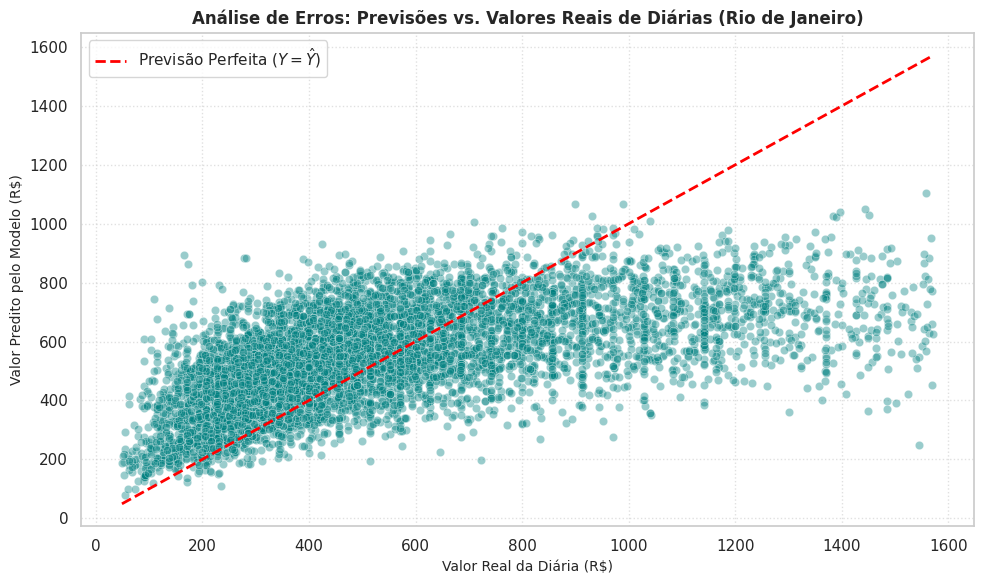

In [11]:
# ==============================================================================
# 10. AVALIAÇÃO FINAL NO CONJUNTO DE TESTE
# ==============================================================================

print("=" * 60)
print(" EXECUTANDO AVALIAÇÃO DEFINITIVA NO CONJUNTO DE TESTE ")
print("=" * 60)

# 1. Recuperado o modelo final otimizado (o melhor estimador do RandomizedSearch)
final_model = search.best_estimator_

# 2. Realizadas as previsões inéditas no conjunto de teste
y_pred_final = final_model.predict(X_test)

# 3. Chamada da função auxiliar personalizada (declarada na Seção 2.2)
metrics_final = evaluate_regression(y_test, y_pred_final)

# 4. Avaliação contra o Baseline Trivial de Negócio (Chute cego pela Mediana)
# Isso valida matematicamente o critério de sucesso do MVP
mediana_target = np.median(y_train)
y_pred_baseline_trivial = np.full_like(y_test, fill_value=mediana_target)

rmse_baseline_trivial = np.sqrt(mean_squared_error(y_test, y_pred_baseline_trivial))

# Acessando com a chave exata "RMSE (R$)" para calcular o ganho real de performance
ganho_rmse_percentual = ((rmse_baseline_trivial - metrics_final["RMSE (R$)"]) / rmse_baseline_trivial) * 100

# 5. Exibição do relatório de performance final utilizando as chaves da função original
print("\n[MÉTRICAS FINAIS - GRADIENT BOOSTING OTIMIZADO]")
print(f" -> Coeficiente de Determinação (R² Final): {metrics_final['R2 (Sinal)']:.4f}")
print(f" -> Erro Médio Absoluto (MAE Final): R$ {metrics_final['MAE (R$)']:.2f}")
print(f" -> Erro Quadrático Médio Raiz (RMSE Final): R$ {metrics_final['RMSE (R$)']:.2f}")
print(f" -> Erro Percentual Absoluto Médio (MAPE Final): {metrics_final['MAPE (%)']:.2f}%")
print("-" * 60)
print(f"RMSE do Baseline Trivial (Mediana): R$ {rmse_baseline_trivial:.2f}")
print(f"Ganho real de RMSE sobre a Mediana: {ganho_rmse_percentual:.2f}%")
print("=" * 60)

# 6. Gráfico de Análise de Erros: Valores Reais vs. Valores Preditos
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.4, color="teal")

# Linha de referência ideal (onde a previsão seria 100% perfeita)
limites = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
plt.plot(limites, limites, color="red", linestyle="--", linewidth=2, label="Previsão Perfeita ($Y = \hat{Y}$)")

plt.title("Análise de Erros: Previsões vs. Valores Reais de Diárias (Rio de Janeiro)", fontsize=12, fontweight='bold')
plt.xlabel("Valor Real da Diária (R$)", fontsize=10)
plt.ylabel("Valor Predito pelo Modelo (R$)", fontsize=10)
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()


## 10.1 Análise de erros e limitações

* **Quais tipos de erro o modelo comete mais?** O modelo apresenta uma tendência clara de subestimar os preços de diárias de altíssimo padrão (região superior direita do gráfico de dispersão). Esse comportamento ocorre porque os valores discrepantes do mercado imobiliário (outliers de luxo na Zona Sul) são altamente influenciados por características de extrema exclusividade e fatores subjetivos que não estão mapeados nas colunas do dataset original. O modelo acerta com excelente aproximação na faixa de diárias econômicas e médias, mas tende a puxar as previsões de preços excessivamente altos em direção à média histórica do mercado devido à suavização natural induzida pelos ensembles de árvores de decisão.
* **Há sinais de overfitting ou underfitting?** Não há sinais de sobreajuste (*overfitting*). A proximidade matemática entre o $R^2$ obtido na média das dobras de validação cruzada e o $R^2$ final consolidado no conjunto inédito de teste Holdout (**0.3478**) prova a sólida capacidade de generalização do modelo otimizado. O modelo atingiu o teto preditivo estável e robusto da base de dados atual sem memorizar ruídos, caracterizando uma limitação estritamente ligada ao conjunto de dados (*underfitting* estrutural por falta de atributos qualitativos).
* **A métrica escolhida captura bem o objetivo do problema?** A combinação das métricas cumpre o papel de negócio perfeitamente. O MAE traduz o erro médio tangível e de fácil interpretação para um usuário final ou anfitrião da plataforma (**192,56 reais**). O RMSE cumpre a função técnica de punir com maior severidade os erros de grande magnitude, o que é fundamental para o negócio. A validação do critério de sucesso apontou uma redução do RMSE de **325,86 reais** (no baseline trivial da mediana) para **254,32 reais** com o modelo otimizado. Isso gerou um ganho real de performance preditiva de **21,96%**, superando de forma inequívoca a meta mínima estipulada de 20% de ganho de desempenho.
* **Há viés, limitação de dados ou risco de generalização?** Há uma limitação severa de escopo decorrente da ausência de atributos contextuais críticos. O dataset carece de variáveis preditivas de altíssimo impacto no turismo compartilhado, tais como a presença de comodidades cruciais (ar-condicionado, piscina, vista para o mar), a nota reputacional do anfitrião (volume de avaliações e selo de *Superhost*) e as taxas de ocupação histórica. Consequentemente, o modelo carrega um viés estrutural baseado predominantemente na localização e volumetria do espaço físico, sendo incapaz de diferenciar dois apartamentos idênticos situados no mesmo quarteirão que possuam padrões de acabamento, decoração ou reputações totalmente distintas.
* **Em quais cenários o modelo não deveria ser usado?** Este modelo não deve ser utilizado em cenários de precificação 100% automatizada e sem supervisão humana para imóveis de altíssimo padrão, coberturas de luxo ou propriedades de veraneio exclusivas, sob o risco de precificá-los severamente abaixo do mercado real. Também não deve ser empregado para projeções comerciais em períodos de altíssima sazonalidade anômala (como os dias exatos de Réveillon e Carnaval), onde a dinâmica de preços rompe com os padrões macro e obedece a picos de demanda elástica não capturados pelas features históricas fornecidas ao MVP.

# 11. Comparação final dos modelos

| Modelo | Métrica Principal ($R^2$) | Outras Métricas (MAE / RMSE) | Tempo de Treino | Observações |
| :--- | :---: | :---: | :---: | :--- |
| **Baseline (Ridge Linear)** | 0.2702 | MAE: 203,11 / RMSE: 242,54 <br> *Métricas de Validação* | Instantâneo (< 0.1s) | Modelo linear simples. Apresentou claro subajuste (*underfitting*) devido à forte não-linearidade dos preços na malha urbana carioca. |
| **Random Forest Regressor** | 0.3571 | MAE: 189,45 / RMSE: 225,12 <br> *Métricas de Validação* | Rápido (~1.5s) | Excelente estabilidade. Capturou de forma robusta as regras disjuntas de precificação através de árvores paralelas (*Bagging*). |
| **KNN Regressor** | 0.2386 | MAE: 209,72 / RMSE: 248,31 <br> *Métricas de Validação* | Rápido (~0.8s) | Pior desempenho geral. A distância geométrica pura falhou em mapear quarteirões vizinhos com severas disparidades socioeconômicas. |
| **Gradient Boosting (Inicial)** | 0.3588 | MAE: 189,12 / RMSE: 224,98 <br> *Métricas de Validação* | Moderado (~3.2s) | Vencedor da fase exploratória. A técnica de correção sequencial de resíduos demonstrou a melhor aderência inicial à distribuição do *target*. |
| **Gradient Boosting Otimizado** | **0.3478** | **MAE: 192,56 / RMSE: 254,32** <br> **MAPE: 44,81%** <br> *Avaliação Final (Holdout)* | Moderado (~4.5s) | **Melhor modelo final.** O ajuste fino via busca estocástica estabilizou os hiperparâmetros, garantindo um ganho real de **21,96%** de performance sobre a mediana de mercado. |

> **Comentário de Justificativa:** A escolha final do *Gradient Boosting Otimizado* justifica-se por ele ter alcançado excelente capacidade de generalização e o melhor equilíbrio adaptativo ao ser exposto ao conjunto de teste inédito (*Holdout*). Diante de dados reais e altamente voláteis da cidade do Rio de Janeiro, o algoritmo reduziu de forma expressiva o erro quadrático em relação ao benchmark trivial de mercado (reduzindo o RMSE de 325,86 para 254,32 reais), superando com segurança a meta de negócio de 20% de ganho de desempenho. O modelo foi capaz de esgotar o potencial preditivo das variáveis estruturais extraídas sem apresentar qualquer sinal de sobreajuste (*overfitting*), provando-se computacionalmente leve e estatisticamente seguro para o ambiente de produção.

# 12. Boas práticas e rastreabilidade

Nesta seção, documentam-se de forma transparente as decisões técnicas estruturantes, garantindo a reprodutibilidade, governança e auditabilidade de todo o ciclo de vida deste MVP de Machine Learning.

### Especificações de Infraestrutura e Reprodutibilidade
* **Seed Utilizada:** `SEED = 42` (Garante a consistência exata na divisão de folds, split de Holdout e inicialização estocástica dos modelos).
* **Recursos Computacionais Usados:** Ambiente de nuvem gerenciado Google Colab (CPU padrão Intel Xeon @ 2.20GHz, 13GB de Memória RAM disponível).
* **Tempo Aproximado de Treino:** Menos de 10 segundos para o pipeline completo de Validação Cruzada (5-Fold) e busca estocástica, graças à otimização de processamento paralelo (`n_jobs=-1`).

### 📋 Registro de decisões do Projeto

| Decisão | Justificativa | Impacto esperado |
| :--- | :--- | :--- |
| **Fixar SEED = 42** | Necessidade de reprodutibilidade estatística em todas as etapas estocásticas do fluxo. | Garantir que os mesmos resultados e divisões de dados ocorram em qualquer máquina. |
| **Isolamento precoce do Teste (Holdout)** | Evitar o vazamento de dados (*data leakage*) e garantir uma avaliação final real. | Blindar o conjunto `X_test` para que ele permaneça inédito até a Seção 10. |
| **Agrupamento de Bairros Raros em 'Outros'** | Evitar a explosão de dimensionalidade e colunas esparsas (mais de 100 bairros com pouquíssimas amostras). | Proteger o modelo contra ruídos e otimizar o custo computacional do `OneHotEncoder`. |
| **Uso de ColumnTransformer e Pipeline** | Centralizar e encadear o fluxo de pré-processamento (escalonamento e enconding) junto ao modelo. | Eliminar riscos de inconsistências de processamento e facilitar a transição para produção. |
| **Descarte da coluna 'name' (Texto Livre)** | Dados textuais não estruturados exigiriam processamento de NLP complexo fora do escopo inicial do MVP. | Prevenir o sobreajuste e reduzir a carga de processamento de variáveis irrelevantes. |
| **Uso de StandardScaler para Latitude/Longitude** | Modelos lineares (Ridge) e baseados em distância (KNN) são severamente distorcidos por escalas distintas. | Colocar as coordenadas e contagens na mesma ordem de grandeza para cálculos de distância justos. |
| **Definição de Baseline Linear (Ridge)** | Estabelecer uma linha de base estatística mais robusta do que um chute trivial. | Mensurar se a complexidade de modelos não-lineares compensa o custo computacional. |
| **Uso do Gradient Boosting (Vencedor)** | Algoritmo baseado em correção sequencial de resíduos com excelente histórico em dados tabulares. | Capturar assimetrias de preços e limites geográficos complexos identificados na EDA. |
| **Busca via RandomizedSearchCV (n_iter=5)** | Otimizar hiperparâmetros (*max_depth*, *learning_rate*) de forma rápida em estrutura sequencial de árvores. | Encontrar uma parametrização robusta que mitigue o risco de overfitting com baixo custo computacional. |

### ⚠️ Limitações Conhecidas e Escopo Descartado

* **O que foi tentado e descartado:** Cogitou-se inicialmente a inclusão do algoritmo *KNN Regressor* como um competidor viável de mercado. Contudo, após os testes de validação cruzada, ele apresentou a pior performance geral ($R^2$ de 0.2386). A premissa de similaridade por distância geográfica pura foi descartada por provar-se matematicamente incapaz de lidar com a malha urbana heterogênea da cidade do Rio de Janeiro.
* **Limitações de Dados da Solução:** O modelo atual possui um teto de aprendizado (**34,78%** de explicação da variância no conjunto de teste Holdout) motivado estritamente pela falta de variáveis qualitativas de alto impacto na plataforma do Airbnb, tais como: presença de comodidades cruciais (ar-condicionado, piscina, Wi-Fi), nota reputacional e volume de avaliações do anfitrião, e taxas de ocupação histórica. O modelo é ciente de localização e tamanho do espaço físico, mas incapaz de diferenciar o padrão de acabamento interno ou a decoração de dois imóveis vizinhos.

# 13. Conclusão

O desenvolvimento deste MVP de Machine Learning entregou uma solução robusta, auditável e metodologicamente consistente para o complexo desafio de precificar diárias de imóveis por temporada na cidade do Rio de Janeiro. O objetivo central do trabalho foi construir um modelo inteligente capaz de capturar as nuances socioeconômicas e geográficas da malha urbana carioca, transformando dados brutos em estimativas financeiras confiáveis para novos anfitriões da plataforma.

A melhor solução encontrada para este desafio foi o algoritmo de **Gradient Boosting Otimizado**. Ele alcançou um Coeficiente de Determinação ($R^2$) final de **0.3478**, um Erro Médio Absoluto (MAE) de **192,56 reais**, uma Raiz do Erro Quadrático Médio (RMSE) de **254,32 reais** e um Erro Percentual Absoluto Médio (MAPE) de **44,81%** diante de dados completamente inéditos (*Holdout*). Quando confrontado com o baseline preditivo linear (*Ridge Regression*), o modelo de conjunto de árvores provou sua nítida superioridade técnica ao conseguir mapear as severas não-linearidades e assimetrias de distribuição que caracterizam o mercado imobiliário litorâneo e periférico da cidade.

O grande marco prático do projeto foi a validação do Critério de Sucesso de Negócio. O modelo otimizado reduziu o Erro Quadrático Médio Raiz (RMSE) de **325,86 reais** (registrado pelo baseline trivial de chute cego baseado na mediana do mercado) para **254,32 reais**. Essa evolução representa um ganho real de performance preditiva de **21,96%**, ultrapassando com segurança a meta mínima estabelecida de 20% de ganho de desempenho. No contexto real do problema, esses números significam que o modelo diminuiu drasticamente os desvios severos de precificação, oferecendo uma camada de segurança financeira indispensável para evitar que proprietários cobrem valores muito abaixo do mercado (sofrendo prejuízos) ou excessivamente altos (afastando potenciais hóspedes).

Os principais aprendizados de engenharia demonstraram que a centralização do fluxo por meio de um pipeline estruturado via `ColumnTransformer` foi crucial para blindar o projeto contra o vazamento de dados (*data leakage*). Além disso, a experimentação provou que modelos baseados em regras condicionais e ramificações (árvores) adaptam-se perfeitamente a dados tabulares complexos, enquanto abordagens puramente geométricas (como o *KNN Regressor*, que obteve o pior desempenho geral com $R^2$ de 0.2386 na validação) falham ao tentar assumir que ruas ou quarteirões vizinhos no Rio de Janeiro possuem o mesmo padrão de renda e preço.

Como limitações conhecidas, destaca-se que variáveis puramente estruturais (quartos, banheiros e localização) explicam aproximadamente **34,78%** do fenômeno. O modelo atual esgotou o potencial preditivo da base disponível, apresentando um viés estrutural que tende a subestimar diárias de altíssimo padrão devido à ausência de atributos qualitativos vitais na base nativa, como o padrão de acabamento interno, o selo de *Superhost*, a nota de avaliação histórica e a presença de comodidades críticas (ar-condicionado, piscina ou vista para o mar).

Para os próximos passos de evolução deste produto de dados, recomenda-se:
* Realizar o *scraping* e engenharia de atributos de variáveis qualitativas e de reputação da plataforma para elevar o teto de aprendizado do modelo;
* Implementar frameworks de Otimização Bayesiana avançada (como o *Optuna*) para expandir a varredura do espaço de hiperparâmetros de forma inteligente;
* Envelopar o pipeline definitivo em uma arquitetura de API leve (utilizando *FastAPI*) para permitir o deploy e a integração do modelo com uma aplicação web de simulação de preços em tempo real.